# Transforms


Matplotlib uses a powerful transformation framework to convert between different coordinate systems. Understanding these transformations is essential for:

- Positioning text and annotations precisely
- Creating custom plots with mixed coordinate systems
- Building complex visualizations

In typical plotting (about 95% of use cases), transformations happen automatically behind the scenes. However, when creating advanced custom visualizations, understanding transforms gives you precise control over element placement. Tranforms can be combine together.

In [15]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.transforms as mtransforms
from matplotlib.patches import Circle, Rectangle, FancyBboxPatch, Ellipse
from matplotlib.lines import Line2D

**Transform** *(abstract base for all transforms, not called directly)*:

- **Affine2DBase** *(base for 2D affine transforms, not called directly)*
    - **Affine2D** — general 2D affine (scale/rotate/translate/shear).
    - **IdentityTransform** — identity affine (no-op).
    - **ScaledTranslation** — translation measured in physical units (points), scaled by another transform (e.g., DPI).
    - **CompositeAffine2D** — composition of two affine transforms (kept as one affine matrix).
    - **BlendedAffine2D** — blended affine: x from one affine, y from another.

    - **NonAffineTransform** — base for non‑affine transforms (e.g., log/polar components used internally by scales).
    - **SeparableTransform** — base where x and y components are independent
        - **BlendedGenericTransform** — blended: x from one transform, y from another (works with non‑affine, too).
    - **CompositeGenericTransform** — sequential composition of two arbitrary transforms (A + B ⇒ apply A then B).
    - **Bbox-related transforms:**
        - **BboxTransformTo** — map unit square [0,1]² to a given Bbox (affine).
        - **BboxTransformFrom** — map from a given Bbox to the unit square (affine).
        - **BboxTransform** — map from a source Bbox to a target Bbox (affine).
        - **OffsetFrom** — offset relative to an artist/bbox by a fixed number of points (screen-space oriented).
    - **TransformWrapper** — wraps a child transform (useful when the child changes dynamically).
    - **FuncTransform** — user-defined forward (and optional inverse) function pair.


```{note}
In this tutorial we will only focus on few transforms only:
- `ax.transData`, it is a type of **CompositeGenericTransform**
- `ax.transAxes` it is a type of **BboxTransformTo**  
- `fig.transFigure`, it is type of **BboxTransformTo**
```

All transforms have the following attributes:
- `.input_dims` - Number of input dimensions
- `.output_dims` - Number of output dimensions
- `is_affine` - Boolean indicating if transform is affine. E.g. True for Affine2D, False for polar transforms
- `is_separable`- Boolean indicating if x and y can be transformed independently
- `has_inverse` - Boolean indicating if inverse transform exists

Main methods:
- `transform(values)`  - Converts input coordinates (usually a list of lists) to output coordinate system. E.g.
```python
ax.transData.transform([[5, 3]]) #  transforms to [[400., 300.]] (pixels)
```
- `transform_path(path)` - Transform a Path object.
- `inverted()` - Returns a transform that reverses this transformation. E.g.
```python
ax.transData.inverted().transform([[400, 300]]) # transforms back to [[5., 3.]] (data coords)
```

### Figure Coordinates: `fig.transFigure`

- Uses **Normalized coordinates** where (0,0) is the bottom-left corner of the **entire figure** and (1,1) is the top-right corner.
- The **range:** is always 0 to 1 in both x and y directions, spanning the entire figure.

**When to use:**
- Positioning elements that span multiple subplots
- Creating figure-level titles or watermarks
- Drawing lines or arrows between different subplots
- Adding logos or stamps to the figure

**Key characteristics:**
- Spans the entire figure including margins
- Independent of axes or subplots
- Useful for figure-level elements
- Includes space outside axes (margins, labels, etc.)

In the following example we specify Normalized Figure Coordinates to put a watermak text and logo. 

In [16]:
# read logo
from pathlib import Path
pth= Path(r'./data')
logo = plt.imread(pth / 'DigAR_Logo.png')

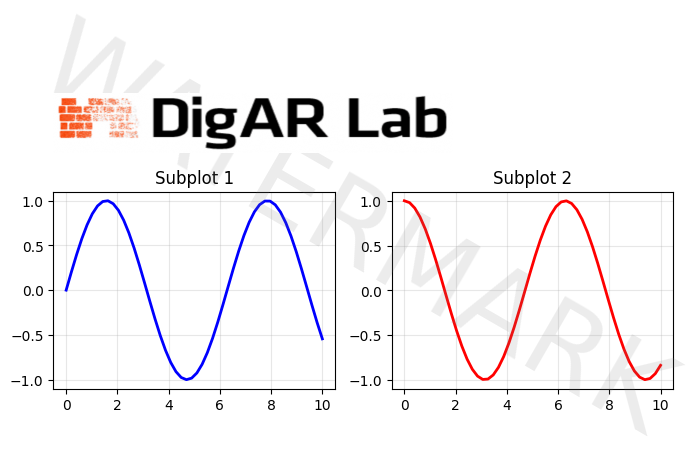

In [17]:
from matplotlib.transforms import Bbox, TransformedBbox
from matplotlib.image import BboxImage

# read logo
from pathlib import Path
pth= Path(r'./data')
logo = plt.imread(pth / 'DigAR_Logo.png')

# create axes
fig = plt.figure(figsize=(8, 4))
gs = fig.add_gridspec(3, 2, wspace= 0.2, hspace= 0.3)  # 3x3 grid
ax1 = fig.add_subplot(gs[0,:], aspect=0.4)
ax2 = fig.add_subplot(gs[1:3 ,0])
ax3 = fig.add_subplot(gs[1:3 ,1])

# Plot data in both subplots
x = np.linspace(0, 10, 50)
ax2.plot(x, np.sin(x), 'b-', lw=2)
ax2.set_title('Subplot 1')
ax2.grid(True, alpha=0.3)

ax3.plot(x, np.cos(x), 'r-', lw=2)
ax3.set_title('Subplot 2')
ax3.grid(True, alpha=0.3)

# Add watermark across entire figure
fig.text(0.5, 0.5, 'WATERMARK', transform=fig.transFigure, #transforming (the figure?) using figure coordinates
         fontsize=80, color='gray', alpha=0.15,
         ha='center', va='center', rotation=-30)

# plot the logo
leftmost = ax2.get_position().bounds[0]
bbox = Bbox.from_bounds(leftmost, 0.7, 0.5, 0.15)
tb = TransformedBbox(bbox, transform= fig.transFigure)
bi = BboxImage(tb, interpolation="bicubic", zorder=5)
bi.set_data(logo)
fig.add_artist(bi)
ax1.axis('off') # remove axis

plt.show()

### Axes Coordinates `ax.transAxes` (*aka Normalized Data Coordinates*)

- Uses **Normalized coordinates** where (0,0) is the bottom-left corner of the **axes** and (1,1) is the top-right corner.
- The **range:** is always 0 to 1 in both x and y directions.

**When to use:** 
- Positioning elements relative to the axes boundaries
- Creating legends, titles, or watermarks that stay in place regardless of data
- Drawing backgrounds or highlights across the entire axes

**Key characteristics:**
- Independent of data limits
- Stays in same relative position when zooming/panning

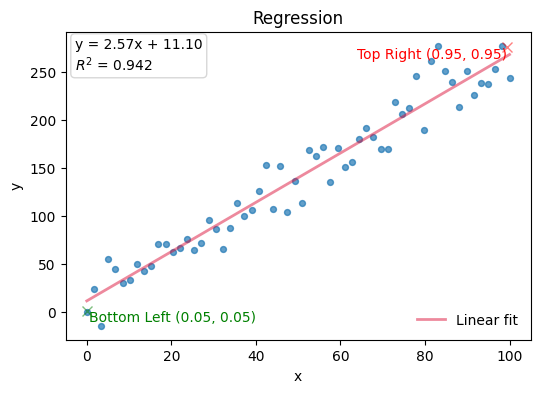

In [18]:
# Create data
rng = np.random.default_rng(2026)
x = np.linspace(0, 100, 60)
y = 2.4 * x + 15 + rng.normal(0, 20, size=x.size)

# Fit a simple linear model
m, b = np.polyfit(x, y, 1)
yhat = m * x + b
r2 = np.corrcoef(x, y)[0, 1] ** 2

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(x, y, s=18, alpha=0.7)
ax.plot(x, yhat, color="crimson", lw=2, label="Linear fit", alpha= 0.5)

# Anchor a text box using axes coordinates

ax.text(0.02, 0.98, f"y = {m:.2f}x + {b:.2f}\n$R^2$ = {r2:.3f}", #anchorpoint using axes coordinatates: scalable with ax size
        transform= ax.transAxes,  # axes-fraction coords (0..1)
        ha="left", va="top", #anchors in place in the figure??
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="lightgrey", alpha=0.9))

# Add text in axes coordinates (independent of data)
ax.plot(0.05, 0.055, 'gx', markersize=7, alpha= 0.5)
ax.text(0.05, 0.05, 'Bottom Left (0.05, 0.05)', ha='left', va='bottom',
        transform= ax.transAxes, size=10, color='green', zorder= 10)

ax.text(0.95, 0.95, 'Top Right (0.95, 0.95)', 
        ha='right', va='top',
        transform= ax.transAxes, size=10, color='red', zorder= 10)
ax.plot(0.95, 0.95, 'rx', markersize=7, transform=ax.transAxes, alpha= 0.5)


ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend(frameon= False)
ax.set_title("Regression")

plt.show()

<a id='coordinate-systems'></a>
### Data Coordinates `ax.transData`

This is the *default*  coordinate system of your actual data values.
- **The range** is determined, by default, by your data **OR** when you set axis limits (e.g., xlim and ylim).

**Key characteristics:**
- Changes when you zoom or pan
- Changes when you set new axis limits
- Most intuitive for plotting actual data
- Default transformation for most plotting functions

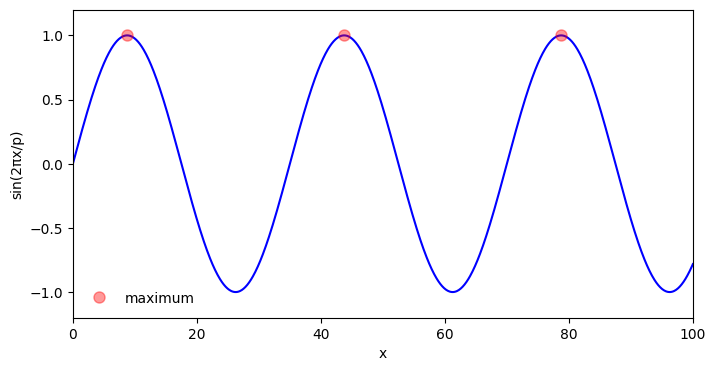

In [19]:
# Sine with controllable period p
p = 35     # period
x = np.linspace(0, 100, 1000)
y = np.sin(2*np.pi*x/p)

fig, ax = plt.subplots(figsize= (8,4))
ax.plot(x, y, color='blue')

# Maxima: x = p/4 + k*p within the plotted range
x0 = p/4
kmax = int(np.floor((x.max() - x0) / p))
xmax = x0 + p * np.arange(kmax + 1)
ymax = np.ones_like(xmax)

# Mark maxima explicitly in data coordinates (transform=ax.transData)
ax.plot(xmax, ymax, 'ro', ms = 8, transform = ax.transData, alpha = 0.4, label = 'maximum')

ax.set_xlim(x.min(), x.max())
ax.set_ylim(-1.2, 1.2)
ax.set_xlabel('x')
ax.set_ylabel('sin(2πx/p)')
ax.legend(frameon= False, loc='lower left')
plt.show()

### Playing with transformations

In [20]:
# create my figure and set limits
fig, ax = plt.subplots(figsize=(6, 5), dpi=100) #600x500 pixels
ax.set_xlim(0,360)
ax.set_ylim(-1,1)
plt.close(fig)

In [21]:
# Define transformations
# DC : Data coordinates (data units)
# FC : Figure coordinates (pixels)
# NDC : Normalized axes (data) coordinates (0 → 1)
# NFC : Normalized figure coordinates (0 → 1)

# Transformation Data to Figure coordinates (NOT NORMALIZED) and viceversa
DC_to_FC = ax.transData
FC_to_DC = ax.transData.inverted()

# Transformation Normalized (Data) Axes to Figure coordinates  (NOT NORMALIZED)
NDC_to_FC = ax.transAxes
FC_to_NDC = ax.transAxes.inverted()

# Transfomration from Normalized Figure to Figure coordinates 
NFC_to_FC = fig.transFigure
FC_to_NFC = fig.transFigure.inverted()

# NEW: Normalized (Data) Axes to Data Axes coordinates
# DC  → FC  → NDC
DC_to_NDC= (DC_to_FC + FC_to_NDC)
NDC_to_DC = DC_to_NDC.inverted()

In [22]:
# data coordinates of the center of the axes?
NDC_to_DC.transform([0.5, 05.]) #middle of 6/5 figure at 100dpi

array([180.,   9.])

In [23]:
# return the pixel coordinates of middle of the figure (figure coords use pixels)
NFC_to_FC.transform([0.5, 0.5])

array([300., 250.])

In [24]:
# return the pixel coordinates of the middle of the axes
NDC_to_FC.transform([0.5, 0.5]) #axes not figure

array([307.5, 247.5])

In [25]:
# Return Axes (Normalized Data) coordinates for this datapoint [180,0]
DC_to_NDC.transform([180, 0])

array([0.5, 0.5])

<a id='individual-transformations'></a>

### Blended Transformations: `blended_transform_factory()`

`blended_transform_factory()` creates a hybrid coordinate system by combining two different transforms - one for the x-axis and one for the y-axis. This allows you to position elements using different coordinate systems for each dimension. Blended transforms are  useful for creating highlights, shaded regions, or annotations that span one axis completely while being constrained in the other.

**Blended Transform Factory main parameters:**
- `x_transform`(first positional argument) - Transform for the x-coordinate.
- `y_transform` (second positional argument) - Transform for the y-coordinate

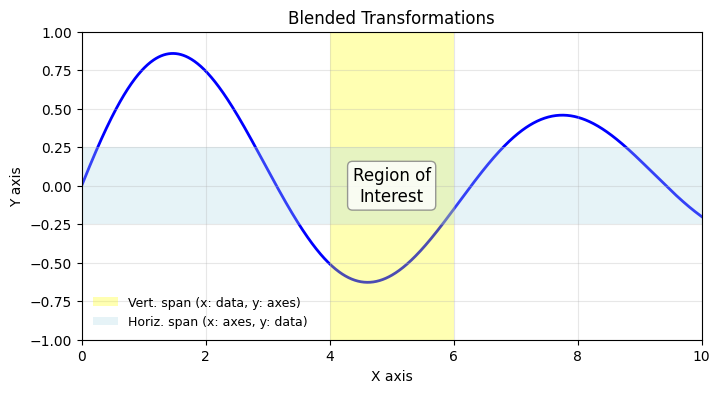

In [26]:
from matplotlib.transforms import blended_transform_factory

# Example 6: Blended Transformations
fig, ax = plt.subplots(figsize=(8, 4))

# Plot data
x = np.linspace(0, 10, 1000)
y = np.sin(x) * np.exp(-x/10)
ax.plot(x, y, 'b-', linewidth=2, zorder= 1)

# Create blended transform: x in data coords, y in normalized axes coords
trans = blended_transform_factory(ax.transData, #when coordinated given, x must be in data space
                                  ax.transAxes) #y must be normalized for axes, 0-1
rect = Rectangle((4, 0),           
                 width= 2.0,        # width is given in relation to Data coordinates
                 height= 1.0,       # height is given in relation to Axes (Normalized Data) coordinates
                 transform=trans,
                 facecolor='yellow', alpha=0.3,
                 label='Vert. span (x: data, y: axes)')
ax.add_patch(rect)


# create inverse blended transform: x in normalized axes coords, y in data coords
inv_trans = blended_transform_factory(ax.transAxes,   # Highlight region from y=4-0.25 to x=60.25, spanning full width
                                      ax.transData) # y in data
rect2 = Rectangle((0, -0.25), 
                  width= 1.0, # width is given in relation to Axes (Normalized Data) coordinates
                  height= 0.5, # height is given in relation to Data coordinates
                  transform=inv_trans,
                  facecolor='lightblue', alpha=0.3,
                  label='Horiz. span (x: axes, y: data)')
ax.add_patch(rect2)

# Add text in the middle of highlighted region
ax.text(5, 0.5, 'Region of\nInterest',
        transform=trans,
        ha='center', va='center',
        fontsize=12, weight='normal',
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='gray', alpha=0.8))

ax.set_xlim(0, 10)
ax.set_ylim(-1, 1)
ax.set_xlabel('X axis')
ax.set_ylabel('Y axis')
ax.set_title('Blended Transformations')
ax.legend(loc='lower left', frameon= False, framealpha= 0, fontsize= 9)
ax.grid(True, alpha=0.3)

plt.show()


```{important}
Matplotlib  offers some shortcuts for the following transformations:
- `blended_transform_factory(ax.transData, ax.transAxes)`  **=** `ax.get_xaxis_transform()`
- `blended_transform_factory(ax.transAxes, ax.transData)`  **=** `ax.get_yaxis_transform()`
```

### Offset Transformations: `offset_copy()`

**Purpose:** Shift elements by a fixed physical distance (points or pixels).

**Use cases:**
- Labels offset from data points
- Shadow effects
- Arrows with fixed offset

Offset transforms are useful when you want elements positioned relative to data points, but with a consistent physical offset that doesn't change with zooming.

**Main offset parameters**

- `trans` (or first positional argument) - The base transform to offset from. E.g. ax.transData, ax.transAxes
- `fig` - Figure instance (required for unit conversions)
- `x` - Horizontal offset amount. Default: 0. E.g. x=10, x=-5
- `y` - Vertical offset amount. Default: 0. E.g. y=15, y=-10
- `units` - Units for the offset values. Options:
    - `'inches'` - Offset in inches (default)
    - `'points'` - Offset in points (1/72 inch)
    - `'dots'` - Offset in display dots/pixels


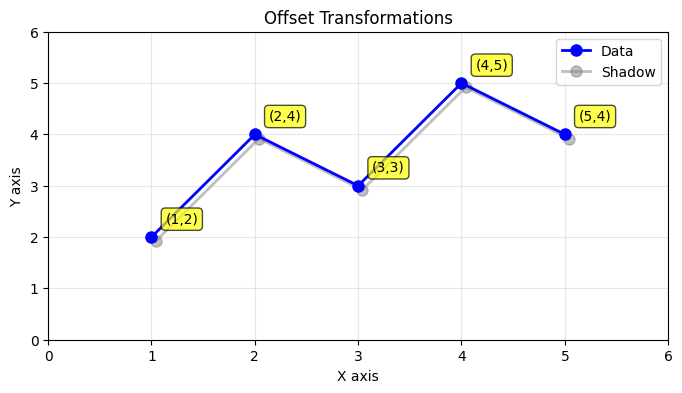

In [27]:
from matplotlib.transforms import offset_copy

# Offset Transformations
fig, ax = plt.subplots(figsize=(8, 4))

# Plot data points
x = np.array([1, 2, 3, 4, 5])
y = np.array([2, 4, 3, 5, 4])
ax.plot(x, y, 'bo-', ms=8, lw=2, label='Data')

# Create offset transform (10 points right, 10 points up)
trans_offset = offset_copy(ax.transData, fig=fig, x=10, y=10, 
                           units='points')#means that the offset is in pixels

# Add labels with consistent offset
for xi, yi in zip(x, y):
    ax.text(xi, yi, f'({xi},{yi})', transform=trans_offset,
            size=10, bbox=dict(boxstyle='round', fc='yellow', alpha=0.7))

# Create shadow effect using offset
shadow_trans = offset_copy(ax.transData, fig=fig,
                            x=3, y=-3, units='points')

ax.plot(x, y, 'o-', color='gray', markersize=8, linewidth=2,
        transform=shadow_trans, zorder=0, alpha=0.5, label='Shadow')

ax.set_xlim(0, 6)
ax.set_ylim(0, 6)
ax.set_xlabel('X axis')
ax.set_ylabel('Y axis')
ax.set_title('Offset Transformations')
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()

### Affine Transformations: `Affine2D()` -- WE STOPPED HERE
* (shifting but not bending)

We can use an affine transformation whenever we want to rotate scale, shear, or translate (i.e. shift) any element. To create an affine transformation, first call `Affine2D` followed by a chain of transformation methods (see below):
- `rotate(theta)` - Rotate by counter-clockwise theta angle in radians.
- `rotate_deg(degrees)` - Rotate by counter-clockwise  theta angle in degrees. 
- `rotate_around(x, y, theta)` - Rotate by counter-clockwise theta angle in radians about (x, y)
- `rotate_deg_around(x, y, theta)` - Rotate by counter-clockwise theta angle in degrees about (x, y)
- `scale(sx, sy=None)` - Scale in x and y directions. *if sy is None, uses sx for both dimensions. E.g.trans.scale(2, 0.5) - double width, halve height
- `translate(tx, ty)` - Translate (shift) in x and y directions.
- `skew(x_shear, y_shear)` - Applies shear transformation in radians; x_shear shears along x-axis, y_shear along y-axis. E.g. trans.skew(0.5, 0) - shear 0.5 radians in x direction
- `skew_deg(x_shear, y_shear)` - Applies shear transformation in degrees; x_shear shears along x-axis, y_shear along y-axis. E.g.trans.skew_deg(30, 0) - shear 30 degrees in x direction
- `clear()` - Resets the transformation matrix to identity (no transformation). E.g. trans.clear() - removes all transformations
- `set_matrix(mtx)` - Sets the 3x3 affine transformation matrix directly. E.g. trans.set_matrix(np.array([[1, 0, 5], [0, 1, 3], [0, 0, 1]])) - custom matrix

```{important}
- Transformations are chained using method calls: `Affine2D().rotate(...).scale(...).translate(...)`
- Transformations are applied in the order called (right-to-left in mathematical terms)
- Usually combined with **data transform** using +: transform + ax.transData
- All angles default to radians unless using `_deg` variants
- Anchor point for rotations, unless around a point, is the origin in whatever coordinate system we are using.
```

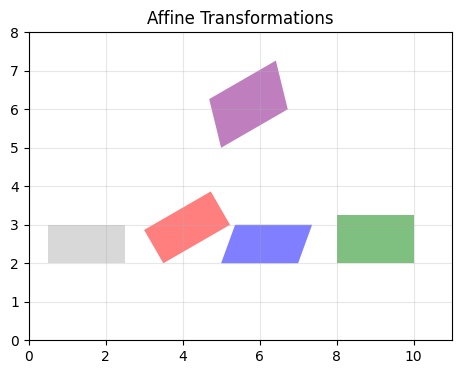

In [38]:
from matplotlib.transforms import Affine2D
# Example 9: Affine Transformations - Rotation
fig, ax = plt.subplots(figsize=(10,4))

# Draw reference rectangle
loc = (0.5, 2.0)
rect_ref = Rectangle(loc, 2, 1, fc='gray', 
                      alpha=0.3, label='Original')
ax.add_patch(rect_ref)

# Rotate 30 degrees
loc= (3.5, 2.0)
trans_rot = (Affine2D().rotate_deg_around(*loc, 30)
            + ax.transData)
rect_rot = Rectangle(loc, 2, 1, fc='red', 
                      alpha=0.5, label='Rotated 30°')
rect_rot.set_transform(trans_rot)
ax.add_patch(rect_rot)

# Skew
loc = (5.0, 2.0)
trans_skew = (Affine2D()
              .translate(-loc[0],-loc[1])#tranforms work in relation to origin so we center there first
              .skew_deg(20,0)
              .translate(*loc)#without moving baack and forth the position get fucked up
              + ax.transData)
rect_skew = Rectangle(loc, 2, 1, fc='blue', 
                       alpha=0.5, label='Skewed 20°')
rect_skew.set_transform(trans_skew)
ax.add_patch(rect_skew)

# Scale by 1.25x
loc= (8.0, 2.0)
trans_scale = (Affine2D()
              .translate(-loc[0],-loc[1])
              .scale(1, 1.25)
              .translate(*loc)
              + ax.transData)
rect_scale = Rectangle(loc, 2, 1, fc='green', 
                        alpha=0.5, label='Scaled 1.25x')
rect_scale.set_transform(trans_scale)
ax.add_patch(rect_scale)


# Combined: rotate + scale + translate
loc= (5.0, 5.0)
trans_combined = (Affine2D()
                  .translate(-loc[0],-loc[1])
                  .skew_deg(20,0)
                  .scale(1, 1.25)
                  .rotate_deg(30)
                  .translate(*loc)
                  + ax.transData)
rect_combined = Rectangle(loc, 2, 1, facecolor='purple', 
                          alpha=0.5, label='Combined transform')
rect_combined.set_transform(trans_combined)
ax.add_patch(rect_combined)

ax.set_xlim(0, 11)
ax.set_ylim(0, 8)
ax.set_aspect('equal')
ax.set_title('Affine Transformations')
# ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.show()

<a id='combining-transformations'></a>
```{important} Combining Transformations 

Transformations can be combined using the `+` operator. The transformation on the **right** is applied **first**, then the one on the left.

> combined = transform1 + transform2 

The above means: **apply transform2 first, then transform1!**

```

### Key Concepts Summary

#### The Four Main Systems:
1. **Data** (`ax.transData`) - Your plot data (default)
2. **Axes (Normalized Data)** (`ax.transAxes`) - 0 to 1 across axes
3. **Figure** (`fig.transFigure`) - 0 to 1 across entire figure

#### Transform Composition:
- Use `+` operator to combine
- Applied **right-to-left**: `A + B` means apply `B` first, then `A`
- Can chain Affine2D: `.scale().rotate().translate()`

#### Common Patterns:
- **Rotation/Scaling**: `Affine2D().rotate_deg(45) + ax.transData`
- **Vertical/Horizontal Spans**: `blended_transform_factory(ax.transData, ax.transAxes)`
- **Offset Labels**: `offset_copy(ax.transData, x=10, y=10, units='points')`

#### Best Practices

1. **Use the simplest coordinate system** - Don't overcomplicate
2. **Prefer helper methods** - Use `ax.get_xaxis_transform()` instead of manual blends
3. **Test at different sizes** - Display coordinates change with figure size
4. **Use axes coordinates for UI elements** - Legends, watermarks stay in place
5. **Chain affine transforms clearly** - `.scale().rotate().translate()` is readable
6. **Document complex transforms** - Future you will thank you
7. **Consider performance** - Complex transforms can slow rendering


## *Complete Function Reference* <a id='function-reference'></a>

### Functions and Methods That Accept Transform Parameters

Below is a comprehensive, organized list of Matplotlib functions and methods that accept coordinate transformation parameters.

#### Axes Methods

**Plotting and Drawing Functions:**
- `ax.text(x, y, s, transform=...)` - Parameter: `transform`
- `ax.annotate(text, xy, xycoords=..., xytext=..., textcoords=...)` - Parameters: `xycoords`, `textcoords`
- `ax.add_patch(patch)` - Patch objects have `transform` attribute
- `ax.add_artist(artist)` - Artist objects have `transform` attribute
- `ax.add_collection(collection)` - Collection objects have `transform` attribute
- `ax.add_line(line)` - Line2D objects have `transform` attribute
- `ax.streamplot(...)` - Parameter: `transform`

#### Patch Classes (matplotlib.patches)

All patch classes accept `transform` parameter:

- `Patch(transform=...)` - Base class
- `Rectangle(xy, width, height, transform=...)`
- `Circle(xy, radius, transform=...)`
- `Ellipse(xy, width, height, angle=0, transform=...)`
- `Polygon(xy, transform=...)`
- `Wedge(center, r, theta1, theta2, transform=...)`
- `Arc(xy, width, height, angle=0, theta1=0, theta2=360, transform=...)`
- `FancyBboxPatch(xy, width, height, boxstyle='round', transform=...)`
- `FancyArrowPatch(posA, posB, transform=...)`
- `ConnectionPatch(xyA, xyB, coordsA, coordsB, ...)` - Parameters: `coordsA`, `coordsB`
- `PathPatch(path, transform=...)`
- `Shadow(patch, ox, oy, transform=...)`

#### Collection Classes (matplotlib.collections)

- `Collection(offset_transform=...)` - Parameter: `offset_transform`
- `LineCollection(segments, transform=...)`
- `PolyCollection(verts, transform=...)`
- `RegularPolyCollection(numsides, sizes=1, transform=..., offset_transform=...)`
- `PatchCollection(patches, transform=...)`
- `CircleCollection(sizes, transform=..., offset_transform=...)`
- `EllipseCollection(widths, heights, angles, transform=..., offset_transform=...)`

#### Line Classes (matplotlib.lines)

- `Line2D(xdata, ydata, transform=...)`
- `AxLine(xy1, xy2, transform=...)`

#### Text Classes (matplotlib.text)

- `Text(x, y, text, transform=...)`
- `Annotation(text, xy, xytext=None, xycoords='data', textcoords=None, ...)`
- `OffsetFrom(artist, ref_coord, unit='points')` - Helper for offset coordinates
- `TextPath(xy, s, transform=...)`

#### Image Functions

- `ax.imshow(X, transform=...)`
- `AxesImage(..., transform=...)`
- `BboxImage(bbox, transform=...)`

#### Transformation Utility Functions

**Creating Transforms:**
- `transforms.Affine2D()` - Create affine transformation
- `transforms.blended_transform_factory(x_transform, y_transform)`
- `transforms.offset_copy(trans, fig=None, x=0, y=0, units='inches')`
- `transforms.ScaledTranslation(xt, yt, scale_trans)`
- `transforms.CompositeGenericTransform(a, b)`
- `transforms.IdentityTransform()`

**Affine2D Methods (chainable):**
- `.clear()` - Reset to identity
- `.rotate(radians)` - Rotate by radians
- `.rotate_deg(degrees)` - Rotate by degrees
- `.rotate_around(x, y, radians)` - Rotate around a point
- `.scale(sx, sy=None)` - Scale x and y
- `.skew(xShear, yShear)` - Skew transformation
- `.skew_deg(xShear, yShear)` - Skew in degrees
- `.translate(tx, ty)` - Translate by (tx, ty)

**Transform Operations:**
- `transform.transform(values)` - Apply transform to points
- `transform.inverted()` - Get inverse transformation
- `transform1 + transform2` - Compose transformations

#### Coordinate System Strings

For `xycoords` and `textcoords` in `annotate()`:

- `'data'` - Data coordinates (default)
- `'axes fraction'` - Axes coordinates (0 to 1)
- `'figure fraction'` - Figure coordinates (0 to 1)
- `'axes points'` - Points from lower-left of axes
- `'figure points'` - Points from lower-left of figure
- `'axes pixels'` - Pixels from lower-left of axes
- `'figure pixels'` - Pixels from lower-left of figure
- `'offset points'` - Offset in points from xy
- `'offset pixels'` - Offset in pixels from xy
- `'polar'` - Polar coordinates (theta, r)

#### Artist Base Class Methods

Available on all plot elements:

- `artist.set_transform(transform)` - Set the transform
- `artist.get_transform()` - Get current transform
- `artist.is_transform_set()` - Check if explicitly set